In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'].head()

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


In [5]:
df['TotalCharges'].dtype

dtype('O')

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(7032, 21)

In [10]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [11]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


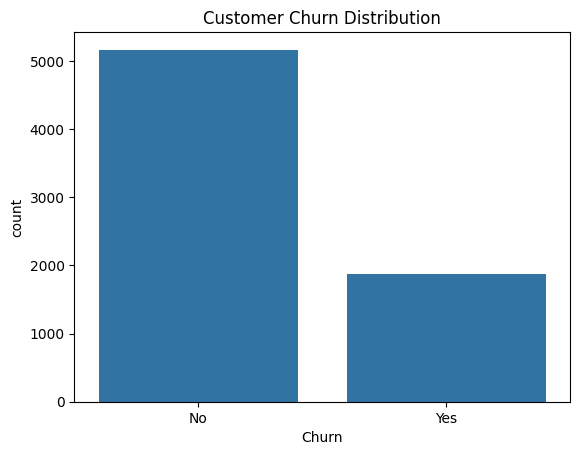

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.show()

In [13]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [14]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


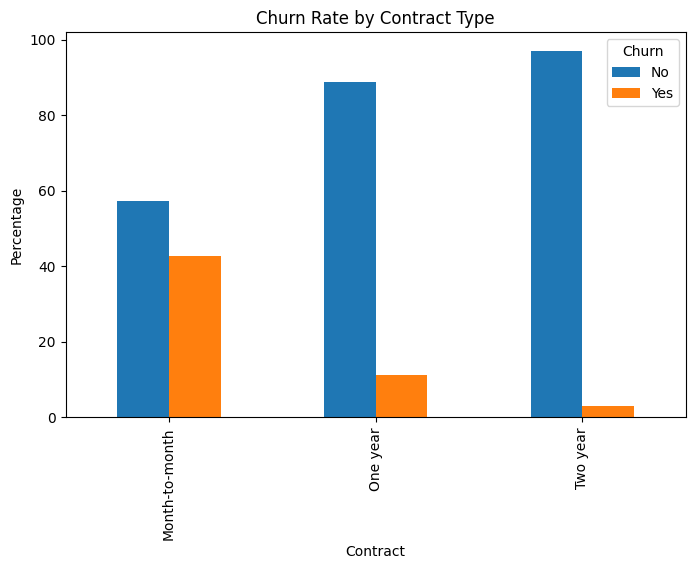

In [15]:
contract_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage')
plt.show()

In [16]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


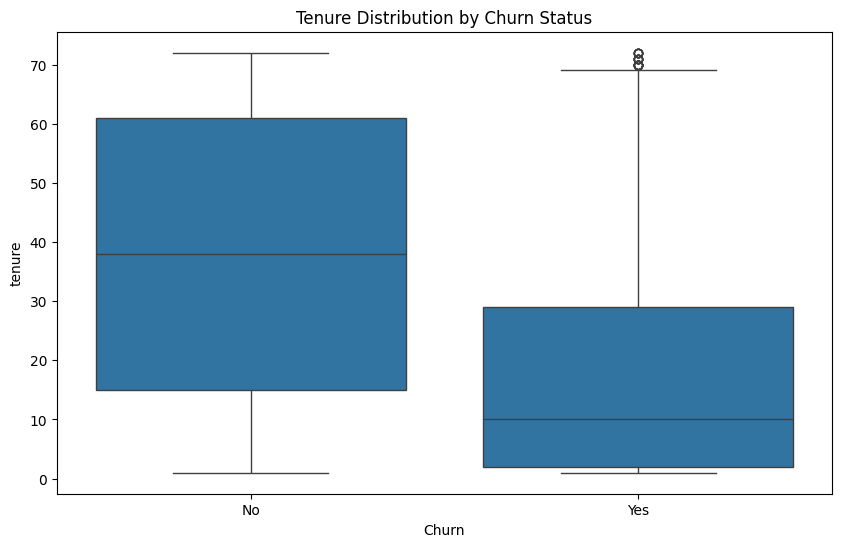

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title('Tenure Distribution by Churn Status')
plt.show()

In [18]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


In [19]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

In [20]:
df['Churn'].head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [21]:
df = df.drop('customerID', axis=1)

In [22]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [23]:
df_encoded.shape

(7032, 31)

In [24]:
X = df_encoded.drop('Churn', axis=1)

y = df_encoded['Churn']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7874911158493249


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[915 118]
 [181 193]]


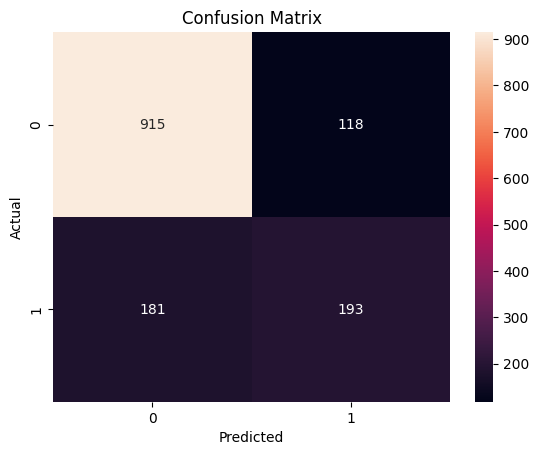

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.667972
26,PaperlessBilling_Yes,0.275182
28,PaymentMethod_Electronic check,0.265597
8,MultipleLines_No phone service,0.264738
0,SeniorCitizen,0.258251
23,StreamingMovies_Yes,0.199863
9,MultipleLines_Yes,0.196662
21,StreamingTV_Yes,0.181474
5,Partner_Yes,0.051264
2,MonthlyCharges,0.004207


In [33]:
feature_importance.sort_values(
    by='Coefficient',
    ascending=True
).head(10)

,Feature,Coefficient
25,Contract_Two year,-1.308117
24,Contract_One year,-0.760510
13,OnlineSecurity_Yes,-0.467520
19,TechSupport_Yes,-0.444962
7,PhoneService_Yes,-0.442127
6,Dependents_Yes,-0.214941
15,OnlineBackup_Yes,-0.141509
27,PaymentMethod_Credit card (automatic),-0.137263
20,StreamingTV_No internet service,-0.089413
18,TechSupport_No internet service,-0.089413


In [34]:
!pip install xgboost

In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

accuracy_score(y_test, y_pred_xgb)

0.8002842928216063

In [36]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_tuned.predict(X_test)

from sklearn.metrics import accuracy_score

print(
    accuracy_score(y_test, y_pred_tuned)
)

0.7917555081734187


## Exploratory Data Analysis

The objective of this section is to identify patterns and factors associated with customer churn.

Key questions explored:

- Does contract type affect churn?
- Does tenure affect churn?
- Do monthly charges affect churn?

# Customer Churn Prediction

## Business Problem

A telecom company wants to identify customers likely to churn and understand the factors driving customer attrition.

## Dataset Overview

- 7032 Customers
- 31 Features
- Telecom Industry

The goal is to build a machine learning model that predicts customer churn and provides actionable business recommendations.

## Data Cleaning

The dataset was inspected for missing values and datatype inconsistencies.

Actions performed:
- Converted TotalCharges to numeric format
- Removed 11 rows containing missing values
- Removed customerID column
- Encoded categorical variables using one-hot encoding